# Calibration analysis — Victim–perpetrator overlap

This notebook evaluates calibration using the already-saved prediction file `predictions_with_probs.csv`. It does not retrain the model and does not alter thresholds.

Required columns:

- `y_true`: observed 0/1 label.
- `y_prob_pos`: predicted score/probability for the positive class.
- `y_pred`: final binary prediction after the selected threshold, used here only for diagnostics.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss, roc_auc_score, average_precision_score, classification_report, confusion_matrix

PREDICTIONS_PATH = 'predictions_with_probs.csv'
MODEL_NAME = 'Victim–perpetrator overlap'
N_BINS = 10


## 1. Load prediction file

For calibration, we use the continuous score before thresholding (`y_prob_pos`), not the binary prediction (`y_pred`).


In [2]:
df_pred = pd.read_csv(PREDICTIONS_PATH)

print(df_pred.shape)
print(df_pred.columns.tolist())
df_pred.head()


(942, 4)
['idx_original', 'y_true', 'y_pred', 'y_prob_pos']


,idx_original,y_true,y_pred,y_prob_pos
0,1,1,0,0.486479
1,2,0,1,0.584005
2,5,0,1,0.588916
3,11,0,1,0.500509
4,13,0,0,0.484886


## 2. Basic checks

The score must be continuous and between 0 and 1. If it has only two unique values, it is probably a thresholded prediction rather than a probability/score.


In [3]:
y_true = df_pred['y_true'].astype(int).to_numpy()
y_score = df_pred['y_prob_pos'].astype(float).to_numpy()
y_pred = df_pred['y_pred'].astype(int).to_numpy() if 'y_pred' in df_pred.columns else (y_score >= 0.5).astype(int)

print('n y_true:', len(y_true))
print('n y_score:', len(y_score))
print('Unique y_true:', np.unique(y_true))
print('Observed prevalence:', y_true.mean())
print('Min score:', y_score.min())
print('Max score:', y_score.max())
print('Mean score:', y_score.mean())
print('Unique scores:', len(np.unique(y_score)))

if len(y_true) != len(y_score):
    raise ValueError('y_true and y_score have different lengths')
if not set(np.unique(y_true)).issubset({0, 1}):
    raise ValueError('y_true must contain only 0/1 values')
if y_score.min() < 0 or y_score.max() > 1:
    print('WARNING: scores are outside the 0-1 range')
if len(np.unique(y_score)) <= 2:
    print('WARNING: y_score has <= 2 unique values; check that this is not y_pred')


n y_true: 942
n y_score: 942
Unique y_true: [0 1]
Observed prevalence: 0.18895966029723993
Min score: 0.337506
Max score: 0.77434886
Mean score: 0.5116344282908705
Unique scores: 942


## 3. Discrimination diagnostics

These are not calibration metrics, but they help distinguish ranking performance from probability calibration.


In [4]:
print(classification_report(y_true, y_pred, digits=4))
print('Confusion matrix:')
print(confusion_matrix(y_true, y_pred))
print('ROC AUC:', roc_auc_score(y_true, y_score))
print('Average precision:', average_precision_score(y_true, y_score))


              precision    recall  f1-score   support

           0     0.9258    0.5550    0.6939       764
           1     0.2975    0.8090    0.4350       178

    accuracy                         0.6030       942
   macro avg     0.6116    0.6820    0.5645       942
weighted avg     0.8071    0.6030    0.6450       942

Confusion matrix:
[[424 340]
 [ 34 144]]
ROC AUC: 0.7489852344255545
Average precision: 0.38867133242240187


## 4. Brier score

The Brier score measures mean squared error between predicted scores and observed outcomes. Lower is better.

A useful reference is the baseline Brier score obtained by predicting the same probability for everyone, equal to the observed prevalence in the test partition.


In [5]:
brier = brier_score_loss(y_true, y_score)
prevalence = y_true.mean()
brier_baseline = brier_score_loss(y_true, np.full_like(y_true, prevalence, dtype=float))

print(f'Brier score: {brier:.4f}')
print(f'Brier baseline prevalence-only: {brier_baseline:.4f}')
print(f'Brier improvement vs baseline: {brier_baseline - brier:.4f}')


Brier score: 0.2431
Brier baseline prevalence-only: 0.1533
Brier improvement vs baseline: -0.0899


## 5. Calibration table by quantile bins

Each bin groups cases with similar predicted scores. A calibrated model should have `mean_predicted_score` close to `observed_prevalence` in each bin.


In [6]:
cal_df = pd.DataFrame({
    'y_true': y_true,
    'y_score': y_score,
    'y_pred': y_pred,
})

cal_df['score_bin'] = pd.qcut(cal_df['y_score'], q=N_BINS, duplicates='drop')

calibration_table = (
    cal_df.groupby('score_bin', observed=True)
          .agg(
              n=('y_true', 'size'),
              min_score=('y_score', 'min'),
              max_score=('y_score', 'max'),
              mean_predicted_score=('y_score', 'mean'),
              observed_prevalence=('y_true', 'mean'),
              predicted_positive_rate=('y_pred', 'mean')
          )
          .reset_index()
)

calibration_table['calibration_error_mean_minus_obs'] = (
    calibration_table['mean_predicted_score'] - calibration_table['observed_prevalence']
)

calibration_table


,score_bin,n,min_score,max_score,mean_predicted_score,observed_prevalence,predicted_positive_rate,calibration_error_mean_minus_obs
0,"(0.337, 0.424]",95,0.337506,0.423865,0.402789,0.052632,0.000000,0.350158
1,"(0.424, 0.447]",94,0.423907,0.446733,0.436303,0.053191,0.000000,0.383112
2,"(0.447, 0.464]",94,0.447099,0.463846,0.456301,0.053191,0.000000,0.403109
3,"(0.464, 0.481]",94,0.463849,0.480944,0.472358,0.106383,0.000000,0.365975
4,"(0.481, 0.503]",94,0.481199,0.502466,0.492229,0.127660,0.138298,0.364569
5,"(0.503, 0.523]",94,0.502545,0.523232,0.512950,0.180851,1.000000,0.332099
6,"(0.523, 0.546]",94,0.523371,0.546218,0.535715,0.159574,1.000000,0.376141
7,"(0.546, 0.577]",94,0.546593,0.576663,0.558811,0.287234,1.000000,0.271577
8,"(0.577, 0.614]",94,0.576857,0.614018,0.594364,0.351064,1.000000,0.243300
9,"(0.614, 0.774]",95,0.614297,0.774349,0.654166,0.515789,1.000000,0.138377


## 6. Calibration curve

The dashed diagonal represents perfect calibration. Points below the line indicate overestimation; points above the line indicate underestimation.


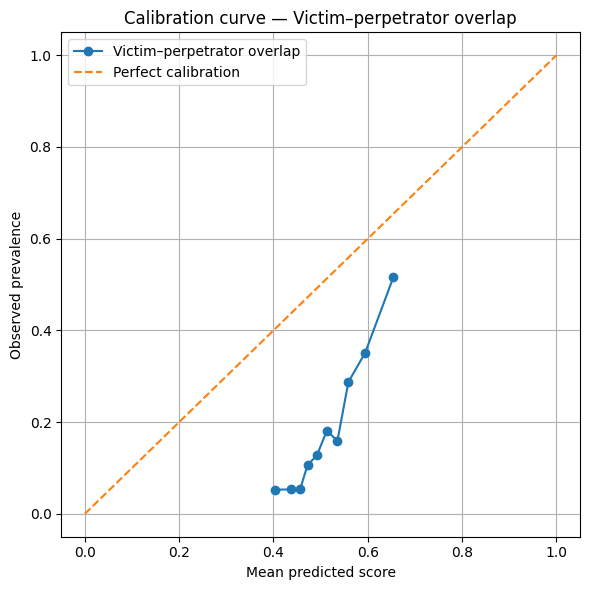

,mean_predicted_score,observed_prevalence
0,0.402789,0.052632
1,0.436303,0.053191
2,0.456301,0.053191
3,0.472358,0.106383
4,0.492229,0.127660
5,0.512950,0.180851
6,0.535715,0.159574
7,0.558811,0.287234
8,0.594364,0.351064
9,0.654166,0.515789


In [7]:
prob_true, prob_pred = calibration_curve(
    y_true,
    y_score,
    n_bins=N_BINS,
    strategy='quantile'
)

calibration_curve_points = pd.DataFrame({
    'mean_predicted_score': prob_pred,
    'observed_prevalence': prob_true,
})

plt.figure(figsize=(6, 6))
plt.plot(prob_pred, prob_true, marker='o', label=MODEL_NAME)
plt.plot([0, 1], [0, 1], linestyle='--', label='Perfect calibration')
plt.xlabel('Mean predicted score')
plt.ylabel('Observed prevalence')
plt.title(f'Calibration curve — {MODEL_NAME}')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('overlap_calibration_curve.png', dpi=200)
plt.show()

calibration_curve_points


## 7. Save outputs


In [8]:
summary = pd.DataFrame([{
    'model': MODEL_NAME,
    'n': len(y_true),
    'observed_prevalence': float(prevalence),
    'mean_predicted_score': float(y_score.mean()),
    'min_score': float(y_score.min()),
    'max_score': float(y_score.max()),
    'unique_scores': int(len(np.unique(y_score))),
    'brier_score': float(brier),
    'brier_baseline_prevalence_only': float(brier_baseline),
    'brier_improvement_vs_baseline': float(brier_baseline - brier),
    'roc_auc': float(roc_auc_score(y_true, y_score)),
    'average_precision': float(average_precision_score(y_true, y_score)),
    'n_negative': int((y_true == 0).sum()),
    'n_positive': int((y_true == 1).sum()),
}])

summary.to_csv('overlap_calibration_summary.csv', index=False)
calibration_table.to_csv('overlap_calibration_table_quantile_bins.csv', index=False)
calibration_curve_points.to_csv('overlap_calibration_curve_points.csv', index=False)

summary


,model,n,observed_prevalence,mean_predicted_score,min_score,max_score,unique_scores,brier_score,brier_baseline_prevalence_only,brier_improvement_vs_baseline,roc_auc,average_precision,n_negative,n_positive
0,Victim–perpetrator overlap,942,0.18896,0.511634,0.337506,0.774349,942,0.243115,0.153254,-0.089862,0.748985,0.388671,764,178
